# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
import pandas as pd

In [3]:
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
#Рассчитаем количество уникальных сессий для каждого уникального пользователя
sessions_history.groupby('user_id')['session_id'].nunique()

user_id
00005FB6A13A6FBE    2
0000B15A18D77ED9    3
0000C4E3A4A571A9    2
000293FAF9E67A81    4
00029C5AE889A6C3    2
                   ..
FFFCDE7746148710    4
FFFDD413285E753F    3
FFFECBA0F2578AB0    2
FFFEDB68228B5F21    5
FFFF4228DF580C3B    3
Name: session_id, Length: 134039, dtype: int64

In [5]:
#Найдем пользователя с наибольшим количеством сессий и выведем для него все данные
max_sessions_user = sessions_history.groupby('user_id')['session_id'].count().idxmax()
user_data = sessions_history[sessions_history['user_id'] == max_sessions_user]
display(user_data)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Как видим из таблицы с данными для пользователя, имеющего наибольшее количество сессий, всего у него было 10 сессий, заходил он практически каждый день, за исключением последних дней, он не зарегистрирован в приложении, также время начала сессий у него всегда было разное, но чаще это было обеденное время между 13-00 и 15-00. Максимальное количество страниц было просмотрено в день установки приложения и на экваторе количества сессий. В основном пользователь просматривал от 2 до 3 страниц. Также пользователь всегда заходил с устройства Андроид.

#### 1.3. Анализ числа регистраций
Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования.

In [6]:
#Преобразуем в тип даты и времени столбец с датой наблюдения
sessions_history['session_start_ts'] = pd.to_datetime(sessions_history['session_start_ts'])

In [7]:
#Посчитаем число уникальных пользователей
unique_users = sessions_history.groupby(sessions_history['session_start_ts'].dt.date)['user_id'].nunique()
print(unique_users)

session_start_ts
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64


In [8]:
#Фильтруем зарегистрированных пользователей
registered_users = sessions_history[sessions_history['registration_flag'] == 1]
#Посчитаем число зарегистрированных пользователей
registered_users_date = registered_users.groupby(registered_users['session_start_ts'].dt.date)['user_id'].count()
print(registered_users_date)

session_start_ts
2025-08-11     169
2025-08-12     336
2025-08-13     464
2025-08-14     625
2025-08-15     840
2025-08-16     916
2025-08-17     833
2025-08-18     860
2025-08-19     831
2025-08-20    1008
2025-08-21    1063
2025-08-22    1251
2025-08-23    1253
2025-08-24    1181
2025-08-25    1060
2025-08-26    1050
2025-08-27    1076
2025-08-28    1175
2025-08-29    1174
2025-08-30    1165
2025-08-31    1105
2025-09-01    1028
2025-09-02    1039
2025-09-03    1035
2025-09-04    1007
2025-09-05    1030
2025-09-06    1023
2025-09-07    1069
2025-09-08    1009
2025-09-09     980
2025-09-10    1015
2025-09-11     824
2025-09-12     669
2025-09-13     537
2025-09-14     440
2025-09-15     383
2025-09-16     286
2025-09-17     272
2025-09-18     201
2025-09-19     132
2025-09-20     107
2025-09-21      87
2025-09-22      68
2025-09-23      32
Name: user_id, dtype: int64


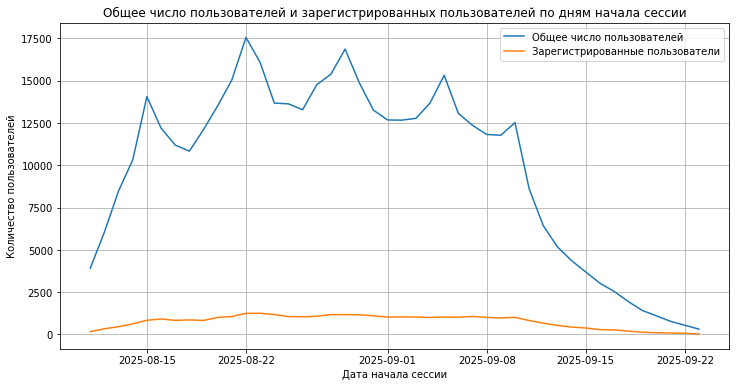

In [9]:
#Постройм линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(sessions_history.groupby(sessions_history['session_start_ts'].dt.date)['user_id'].count(), 
         label='Общее число пользователей')
plt.plot(registered_users.groupby(registered_users['session_start_ts'].dt.date)['user_id'].count(), 
         label='Зарегистрированные пользователи')

plt.xlabel('Дата начала сессии')
plt.ylabel('Количество пользователей')
plt.title('Общее число пользователей и зарегистрированных пользователей по дням начала сессии')
plt.legend()
plt.grid(True)
plt.show()


Исходя из графика видим, что общее число пользователей сильно выше числа зарегистрированных пользователей, но их количество постепенно снижается, рассчитаем долю зарегистрированных пользователей от общего числа:

In [10]:
percentage = registered_users_date / unique_users

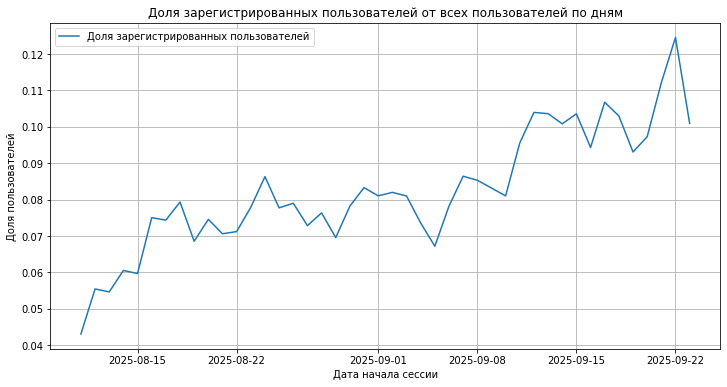

In [11]:
#Построим линейный график доли зарегистрированных пользователей от всех пользователей по дням
plt.figure(figsize=(12, 6))
plt.plot(percentage, label='Доля зарегистрированных пользователей')

plt.xlabel('Дата начала сессии')
plt.ylabel('Доля пользователей')
plt.title('Доля зарегистрированных пользователей от всех пользователей по дням')
plt.legend()
plt.grid(True)
plt.show()

Видим, что доля зарегистрированных пользователей имеет положительную динамику: с каждым днем их число становится выше, хотя и скачкообразно

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

In [12]:
#Найдем количество сессий для каждого значения количества просмотренных страниц
sessions_history.groupby('page_counter')['session_id'].count()

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

In [13]:
import matplotlib.pyplot as plt

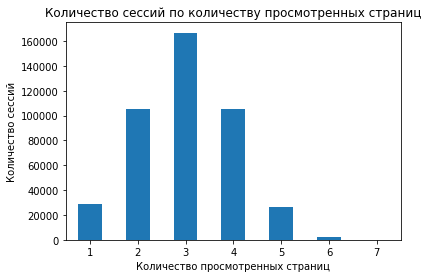

In [14]:
# Строим гистограмму
ax = sessions_history.groupby('page_counter')['session_id'].count().plot.bar()
ax.set_title('Количество сессий по количеству просмотренных страниц')
ax.set_xlabel('Количество просмотренных страниц')
ax.set_ylabel('Количество сессий')
plt.xticks(rotation=360) 
plt.show()

Как можем заметить из графика: наибольшее количество сессий приходится на 3 просмотренные страницы, а на 2 и 4 просмотренные страницы приходится практически одинаковое количество сессий, реже просматривают 1, 5 и еще реже 6 и 7 страниц.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

In [15]:
def pages(page_counter):
    if page_counter >= 4:
        return 1
    else:
        return 0

# Применение функции к столбцу page_counter и создание нового столбца good_session
sessions_history['good_session'] = sessions_history['page_counter'].apply(pages)

In [16]:
#Посчитаем количество всех сессий по дням за весь период наблюдения
count_sessions = sessions_history.groupby(sessions_history['session_start_ts'].dt.date)['session_id'].count()
print(count_sessions)

session_start_ts
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: session_id, dtype: int64


In [17]:
#Посчитаем количество успешных сессий по дням за весь период наблюдения
lucky_sessions = sessions_history.groupby(sessions_history['session_start_ts'].dt.date)['good_session'].sum()
print(lucky_sessions)

session_start_ts
2025-08-11    1226
2025-08-12    1829
2025-08-13    2604
2025-08-14    3262
2025-08-15    4289
2025-08-16    3737
2025-08-17    3557
2025-08-18    3366
2025-08-19    3791
2025-08-20    4148
2025-08-21    4563
2025-08-22    5500
2025-08-23    4858
2025-08-24    4239
2025-08-25    4165
2025-08-26    4132
2025-08-27    4594
2025-08-28    4779
2025-08-29    5283
2025-08-30    4673
2025-08-31    4013
2025-09-01    3964
2025-09-02    3998
2025-09-03    3886
2025-09-04    4317
2025-09-05    4656
2025-09-06    3983
2025-09-07    3860
2025-09-08    3652
2025-09-09    3599
2025-09-10    3822
2025-09-11    2627
2025-09-12    1941
2025-09-13    1550
2025-09-14    1343
2025-09-15    1131
2025-09-16     946
2025-09-17     816
2025-09-18     571
2025-09-19     451
2025-09-20     332
2025-09-21     224
2025-09-22     169
2025-09-23      92
Name: good_session, dtype: int64


In [18]:
#Посчитаем долю успешных сессий от общего количества по дням за весь период наблюдения
percentage_lucky_sessions = lucky_sessions/count_sessions

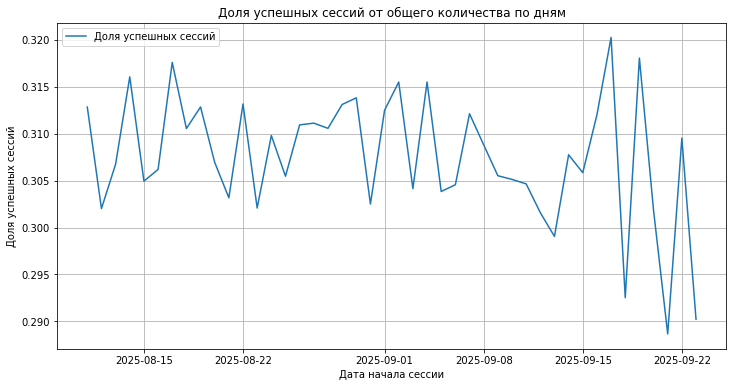

In [19]:
#Построим линейный график доли успешных сессий от общего количества по дням за весь период наблюдения
plt.figure(figsize=(12, 6))
plt.plot(percentage_lucky_sessions, label='Доля успешных сессий')

plt.xlabel('Дата начала сессии')
plt.ylabel('Доля успешных сессий')
plt.title('Доля успешных сессий от общего количества по дням')
plt.legend()
plt.grid(True)
plt.show()

Исходя из графика, видим, что доля успешных сессий имеет в среднем значения от 0,31 до 0,315. Много это или мало - сложно сказать, так как нужно посмотреть конверсию относительно 2х и 3х просмотренных страниц, так как, например, у пользователя с наибольшим количеством сессий именно такое количество страниц превалировало

### 2. Подготовка к тесту

#### 2.1 Формулировка нулевой и альтернативной гипотез

Думаю, что речь идет о доле успешных сессий

Нулевая гипотеза (H0): новый алгоритм не оказывает значимого влияния на долю успешных сессий по сравнению с текущим алгоритмом.

H(0)=H(1)

Альтернативная гипотеза (H1): новый алгоритм улучшает долю успешных сессий по сравнению с текущим алгоритмом.

H(0)<H(1)

#### 2.2. Расчёт размера выборки

In [20]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2 # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p1 = 0.3 # Базовый уровень доли
mde = 0.03 * p1  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


Полученный размер выборки для каждой группы составляет 41 тысячу, то есть для анализа двух групп нам понадобится 82 тысячи пользователей

#### 2.3. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

In [21]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby(sessions_history['session_start_ts'].dt.date)['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [22]:
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

In [23]:
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [24]:
#Фильтруем пользователей группы А
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']

#Фильтруем пользователей группы B
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']

#Преобразуем тип данных в столбце с датой в тип даты и времени
sessions_test_part['session_start_ts'] = pd.to_datetime(sessions_test_part['session_start_ts'])

In [25]:
# Подсчёт уникальных пользователей для группы A
unique_users_group_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby(sessions_test_part['session_start_ts'].dt.date)['user_id'].nunique()

# Подсчёт уникальных пользователей для группы B
unique_users_group_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby(sessions_test_part['session_start_ts'].dt.date)['user_id'].nunique()

print(unique_users_group_a, unique_users_group_b)

session_start_ts
2025-10-14    1477
Name: user_id, dtype: int64 session_start_ts
2025-10-14    1466
Name: user_id, dtype: int64


In [26]:
#Рассчитаем процентную разницу в количестве пользователей в группах A и B
percent = 100 * abs(unique_users_group_a - unique_users_group_b) / unique_users_group_a
print(percent)

session_start_ts
2025-10-14    0.744753
Name: user_id, dtype: float64


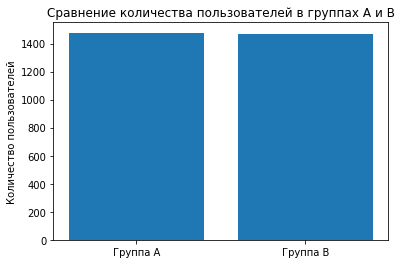

In [27]:
#Извлечение значений
unique_users_group_a_value = unique_users_group_a.values[0]
unique_users_group_b_value = unique_users_group_b.values[0]

#Построение диаграммы
plt.bar(['Группа А', 'Группа В'], [unique_users_group_a_value, unique_users_group_b_value])
plt.ylabel('Количество пользователей')
plt.title('Сравнение количества пользователей в группах A и B')
plt.show()

Видим, что различия в двух группах визуально нет, также и процентная разница составила 0,74%, что подтверждает график

#### 3.2. Проверка пересечений пользователей
- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [28]:
gr_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
gr_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(gr_a) & set(gr_b))
print(intersection) 

[]


Видим, что в список не попал ни один из идентификаторов пользователя. Значит, пересечений между группами нет

#### 3.3. Равномерность разделения пользователей по устройствам

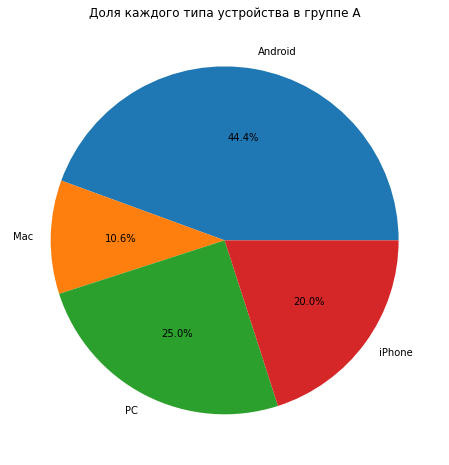

In [29]:
# Считаем общее количество устройств в группе А и долю каждого для группы А
group_a_devices = group_a.groupby('device')['user_id'].nunique()
total = group_a_devices.sum()
device_shares = group_a_devices / total

# Строим круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(device_shares, labels=device_shares.index, autopct='%1.1f%%')
plt.title('Доля каждого типа устройства в группе А')
plt.show()


Видим, что среди устройств в группе А больше всего пользователей пользуются Андроидом

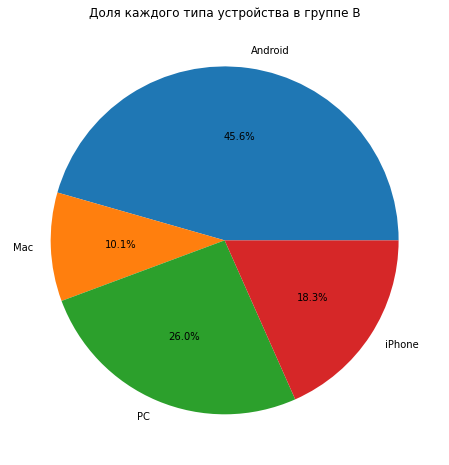

In [30]:
# Считаем общее количество устройств в группе В и долю каждого для группы В
group_b_devices = group_b.groupby('device')['user_id'].nunique()
total_b = group_b_devices.sum()
device_shares_b = group_b_devices / total_b

# Строим круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(device_shares_b, labels=device_shares_b.index, autopct='%1.1f%%')
plt.title('Доля каждого типа устройства в группе В')
plt.show()

В группе В также больше всего пользователей пользуются Андроидом

Распределение долей каждого устройства в двух группах практически одинаково, есть лишь небольшое различие в доле устройства iPhone, составляющее 1,7%, что, на мой взгляд, не критично

#### 3.4. Равномерность распределения пользователей по регионам

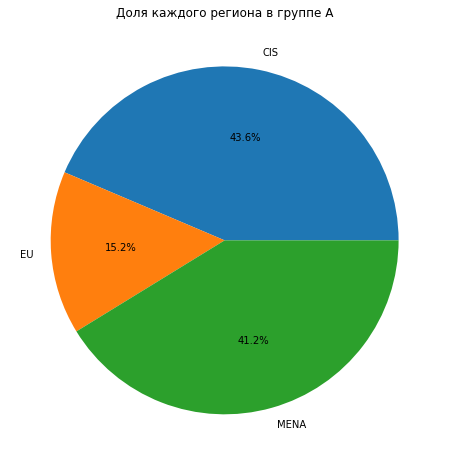

In [31]:
# Считаем общее количество регионов в группе А и долю каждого для группы А
group_a_region = group_a.groupby('region')['user_id'].nunique()
total_a_region = group_a_region.sum()
region_shares_a = group_a_region / total_a_region

# Строим круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(region_shares_a, labels=region_shares_a.index, autopct='%1.1f%%')
plt.title('Доля каждого региона в группе А')
plt.show()

Больше всего пользователей группы А находятся в регионе CIS

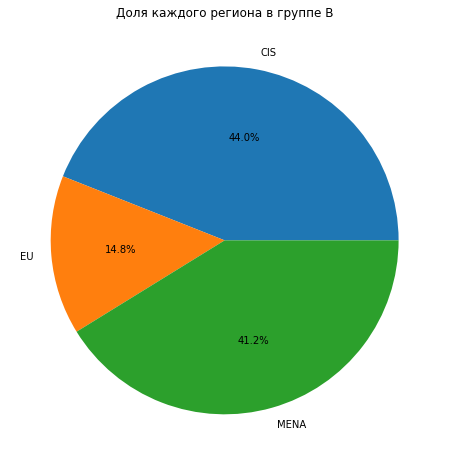

In [32]:
# Считаем общее количество регионов в группе А и долю каждого для группы А
group_b_region = group_b.groupby('region')['user_id'].nunique()
total_b_region = group_b_region.sum()
region_shares_b = group_b_region / total_b_region

# Строим круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(region_shares_b, labels=region_shares_b.index, autopct='%1.1f%%')
plt.title('Доля каждого региона в группе B')
plt.show()

Больше всего пользователей группы B также находятся в регионе CIS

Различия распределения пользователей двух групп по регионам несущественные, все они составляют менее 1%

#### 3.5. Вывод после проверки A/B-теста

На основе проведенного анализа A/B теста видим:

- Есть небольшое различие в количестве пользователей в двух группах, в группе А их количество несколько больше (на 11 пользователей). 

- Анализ по уровню вовлечения пользователей после внедрения алгоритма показывает более высокие результаты именно в группе В (практически на 10%).

- Выборки являются независимыми, пересечения в пользователях между двух групп не было обнаружено

- Распределение пользователей по устройствам и по регионам равномерно, есть небольшое различие в 1,7% распределения по устройствам и в 0,2% распределения по регионам, что не является критичным.

Резюмируя, в целом А/В тест проходит корректно, выборки пользователей и их распределение по устройствам, регионам является равномерным

### 4. Проверка результатов A/B-теста

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [33]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [34]:
def pages(page_counter):
    if page_counter >= 4:
        return 1
    else:
        return 0

# Применение функции к столбцу page_counter и создание нового столбца good_session
sessions_test['good_session'] = sessions_test['page_counter'].apply(pages)

#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и мы будем сравнивать две сопоставимые группы.

In [35]:
#Преобразуем столбец с датой в формат datetime
sessions_test['session_start_ts'] = pd.to_datetime(sessions_test['session_start_ts'])

# Группируем данные по дате и группе, считаем количество уникальных сессий
unique_sessions_per_day = sessions_test.groupby([sessions_test['session_start_ts'].dt.date, 'test_group'])['session_id'].nunique()

display(unique_sessions_per_day)

session_start_ts  test_group
2025-10-14        A             1502
                  B             1628
2025-10-15        A             2235
                  B             2283
2025-10-16        A             3280
                  B             3241
2025-10-17        A             4089
                  B             4054
2025-10-18        A             5013
                  B             5059
2025-10-19        A             6535
                  B             6779
2025-10-20        A             5837
                  B             6089
2025-10-21        A             3927
                  B             3981
2025-10-22        A             3083
                  B             3111
2025-10-23        A             2470
                  B             2548
2025-10-24        A             2090
                  B             2068
2025-10-25        A             1897
                  B             1814
2025-10-26        A             1669
                  B             1692
2025-10-2

Видим, что количество уникальных сессий различается в двух группах, проведем статистический тест Манна-Уитни для сравнения средних тенденций между выборками:

За нулевую гипотезу (H0) примем, что распределение метрики в группах А и В равны

За альтернативную гипотезу (Н1) примем, что распределение метрики в группах А и В не равны

In [36]:
from scipy.stats import mannwhitneyu

# Разделяем данные на две выборки по группам A и B
group_a_sessions = sessions_test[sessions_test['test_group'] == 'A'].groupby(sessions_test['session_start_ts'].dt.date)['session_id'].nunique()
group_b_sessions = sessions_test[sessions_test['test_group'] == 'B'].groupby(sessions_test['session_start_ts'].dt.date)['session_id'].nunique()

alpha = 0.05
mw_test = mannwhitneyu(
    group_a_sessions, # Выборка значений метрики для группы А
    group_b_sessions, # Выборка значений метрики для группы B
    alternative='two-sided' # Выбираем двустороннюю гипотезу 
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются')

pvalue=0.8817307917391243 > 0.05
Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны


Видим, что полученное значение p-value больше уровня статистической значимости, а значит, что распределение количества уникальных дневных сессий в двух выборках не различается

#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [37]:
# Рассчитываем долю успешных сессий для группы A
group_a_success_rate = (sessions_test[sessions_test['test_group'] == 'A']['good_session'].mean())

# Рассчитываем долю успешных сессий для группы B
group_b_success_rate = (sessions_test[sessions_test['test_group'] == 'B']['good_session'].mean())

# Вычисляем разницу в доле успешных сессий
difference_in_success_rates = group_a_success_rate - group_b_success_rate

# Отображаем результаты
print(f"Доля успешных сессий для группы A: {group_a_success_rate}")
print(f"Доля успешных сессий для группы B: {group_b_success_rate}")
print(f"Разница в доле успешных сессий: {difference_in_success_rates}")


Доля успешных сессий для группы A: 0.3077233557344958
Доля успешных сессий для группы B: 0.31828992745867524
Разница в доле успешных сессий: -0.010566571724179463


Исходя из результатов, видим, что доля успешных сессий в двух группах очень близка по значениям друг к другу, однако, в группе В доля успешных сессий несколько выше, чем в группе А

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

За нулевую гипотезу (H0) примем, что доля сессий в группах А и В не различается

За альтернативную гипотезу (Н1) примем, что доля сессий в группе В больше, чем в группе А

In [38]:
from statsmodels.stats.proportion import proportions_ztest

n_a = sessions_test[ # посчитайте размер группы A
    sessions_test.test_group=='A'
].shape[0] 

n_b = sessions_test[ # посчитайте размер группы B
    sessions_test.test_group=='B'
].shape[0]

m_a = sessions_test[ # посчитайте кол-во успехов в группе A
    (sessions_test.test_group=='A')&(sessions_test.good_session==1)
].shape[0] 

m_b = sessions_test[ # посчитайте количество успехов в группе B
     (sessions_test.test_group=='B')&(sessions_test.good_session==1)
].shape[0]

p_a, p_b = m_a/n_a, m_b/n_b # посчитайте доли успехов для каждой группы: A и B

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # проверьте предпосылку о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha =  0.05 # уровень значимости


stat_ztest, p_value_ztest = proportions_ztest( # проведите Z-тест пропорций
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

print(f'pvalue={p_value_ztest}') # выведите полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')
    
if p_value_ztest < alpha:
    if p_a > p_b:
        text_interpretation = 'сократилось'
    elif p_a < p_b:
        text_interpretation = 'увеличилось'
else:
    text_interpretation = 'не изменилось'
 # напишите одно из выражений ("сократилось", "не изменилось", "увеличилось")

print(f'При вводе нового алгоритма количество успешных сессий у тестовой группы {text_interpretation}')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.0001574739988036123
Нулевая гипотеза не находит подтверждения!
При вводе нового алгоритма количество успешных сессий у тестовой группы увеличилось


Видим, что количество успешных сессий в тестовой выборке выше, чем в контрольной, и это значение статистически значимо

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведенного анализа результатов теста можно сделать следующие выводы:

- Количество задействованных пользователей в двух группах различалось: в группе А было большее число пользователей, чем в группе А. Однако, распределение относительно двух групп не различалось из результатов проведенного статистического теста

- Длительность эксперимента была достаточной, так как удалось заметить видимые различия в двух группах на протяжении длительности всего эксперимента

- Внедрение нового алгоритма рекомендаций повлияло на уровень вовлечения пользователей: количество успешных сессий в тестовой группе возросло относительно контрольной. Об этом говорит анализ числа просмотренных страниц между двумя группами и результат анализа статистического теста

- Значение p_value для оценки статистической значимости выявленного эффекта составило 0.00015. Количество успешных сессий у тестовой группы увеличилось

- Нововведение стоит внедрять в приложение, так как это положительно влияет на ключевую метрику: вовлечение пользователей в приложении растет, т.к. растет количество просматриваемых страниц и регистраций